# 📊 Ames Real Estate Valuation: Monotonic XGBoost Model Training & Benchmarking

**Objective**: Benchmark OLS Linear Regression, Random Forest Ensembles, and Monotonic XGBoost Regressors across 5-Fold Cross Validation ($R^2$, RMSE, MAE) and evaluate Explainable AI (XAI) feature importances.

---

## 1. Environment Setup & Data Pipeline

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Path resolution
data_path = Path('../data/AmesHousing.csv')
if not data_path.exists():
    data_path = Path('data/AmesHousing.csv')

df_raw = pd.read_csv(data_path)
df_clean = df_raw[(df_raw['Gr Liv Area'] < 4000) & (df_raw['SalePrice'] > 0)].copy()

qual_map = {'Very_Poor': 1, 'Poor': 2, 'Fair': 3, 'Below_Average': 4, 'Average': 5, 'Above_Average': 6, 'Good': 7, 'Very_Good': 8, 'Excellent': 9, 'Very_Excellent': 10}
exter_map = {'Po': 1, 'Poor': 1, 'Fa': 2, 'Fair': 2, 'TA': 3, 'Typical': 3, 'Average': 3, 'Gd': 4, 'Good': 4, 'Ex': 5, 'Excellent': 5}

if df_clean['Overall Qual'].dtype == object:
    df_clean['Overall Qual'] = df_clean['Overall Qual'].map(qual_map).fillna(5)
df_clean['Overall Qual'] = pd.to_numeric(df_clean['Overall Qual'], errors='coerce').fillna(5).astype(float)

df_clean['Exter_Qual'] = df_clean['Exter_Qual'].map(exter_map).fillna(3).astype(float)
df_clean['Kitchen_Qual'] = df_clean['Kitchen_Qual'].map(exter_map).fillna(3).astype(float)

num_cols = ['Overall_Cond', 'Gr Liv Area', 'Total_Bsmt_SF', 'First_Flr_SF', 'Second_Flr_SF', 'Garage_Area', 'Garage Cars', 'Full Bath', 'Half_Bath', 'Bsmt_Full_Bath', 'Bedroom AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Lot_Area', 'Wood_Deck_SF', 'Open_Porch_SF', 'Year Built', 'Year_Remod_Add']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(float)

df_clean['Qual_Area_Interaction'] = df_clean['Overall Qual'] * df_clean['Gr Liv Area']
df_clean['Total_Living_SF'] = df_clean['Gr Liv Area'] + df_clean['Total_Bsmt_SF']

feature_cols = [
    'Overall Qual', 'Overall_Cond', 'Gr Liv Area', 'Total_Bsmt_SF',
    'First_Flr_SF', 'Second_Flr_SF', 'Garage_Area', 'Garage Cars',
    'Full Bath', 'Half_Bath', 'Bsmt_Full_Bath', 'Bedroom AbvGr',
    'TotRms_AbvGrd', 'Fireplaces', 'Lot_Area', 'Wood_Deck_SF',
    'Open_Porch_SF', 'Year Built', 'Year_Remod_Add', 'Exter_Qual',
    'Kitchen_Qual', 'Qual_Area_Interaction', 'Total_Living_SF'
]

X = df_clean[feature_cols].copy()
y = df_clean['SalePrice'].astype(float)

print(f"[SUCCESS] Cleaned Feature Matrix: {X.shape[0]} rows, {X.shape[1]} features.")

[SUCCESS] Cleaned Feature Matrix: 2925 rows, 23 features.


## 2. 5-Fold Cross-Validation Model Benchmark

In [2]:
monotone_constraints = "(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)"
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=150, random_state=42),
    "Monotonic XGBoost Regressor": xgb.XGBRegressor(
        n_estimators=250,
        learning_rate=0.04,
        max_depth=5,
        subsample=0.85,
        colsample_bytree=0.85,
        monotone_constraints=monotone_constraints,
        random_state=42
    )
}

results = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X, y, cv=kf,
        scoring={'r2': 'r2', 'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error'}
    )
    mean_r2 = cv_res['test_r2'].mean()
    mean_rmse = -cv_res['test_rmse'].mean()
    mean_mae = -cv_res['test_mae'].mean()
    results.append({
        "Model Paradigm": name,
        "R^2 Score": round(mean_r2, 4),
        "RMSE ($)": f"${mean_rmse:,.2f}",
        "MAE ($)": f"${mean_mae:,.2f}"
    })

pd.DataFrame(results)

## 3. Production Monotonic XGBoost Feature Importances (Gain Weight)

In [3]:
prod_model = models["Monotonic XGBoost Regressor"]
prod_model.fit(X, y)

importances = prod_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': (importances * 100).round(2)
}).sort_values('Importance (%)', ascending=False)

feat_imp.head(10)

## 4. Visualizing Feature Importance Distribution

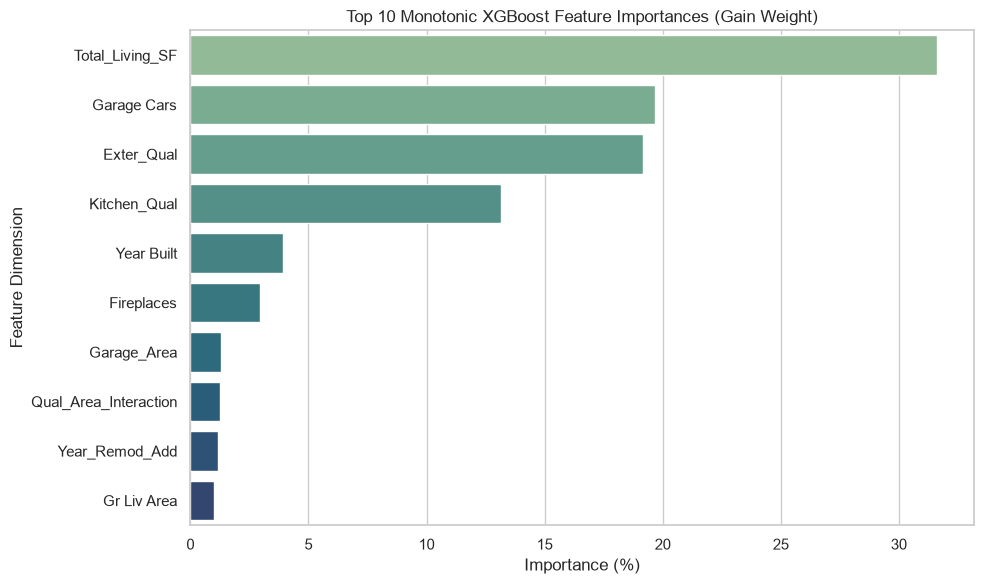

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(10), x='Importance (%)', y='Feature', palette='crest')
plt.title('Top 10 Monotonic XGBoost Feature Importances (Gain Weight)')
plt.xlabel('Importance (%)')
plt.ylabel('Feature Dimension')
plt.tight_layout()
plt.show()